# Nairobi House Price Prediction: End-to-End Machine Learning Pipeline

In [2]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, PolynomialFeatures
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


## 2. Load and Understand Data

In [3]:
#Load the dataset
df = pd.read_csv('nairobi_house_prices.csv')
print(df.shape)
display(df.head())
df.info()
display(df.describe(include='all').T)


(204, 7)


,Price,propertyType,Location,Bedroom,bathroom,House size,Land size
0,KSh 350 000 000,Townhouse,Runda,4.0,4.0,NaN,0.5 acres
1,KSh 30 000 000,Vacant Land,Karen,NaN,NaN,NaN,0.5 acres
2,KSh 325 000 000,Vacant Land,Westlands,NaN,NaN,NaN,0.5 acres
3,KSh 80 000 000,Townhouse,Kitisuru,5.0,5.0,NaN,0.5 acres
4,KSh 25 500 000,Apartment,Kileleshwa,4.0,4.0,230 m²,NaN


<class 'pandas.DataFrame'>
RangeIndex: 204 entries, 0 to 203
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Price         204 non-null    str    
 1   propertyType  204 non-null    str    
 2   Location      204 non-null    str    
 3   Bedroom       183 non-null    float64
 4   bathroom      181 non-null    float64
 5   House size    99 non-null     str    
 6   Land size     64 non-null     str    
dtypes: float64(2), str(5)
memory usage: 18.8 KB


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Price,204,98,KSh 16 000 000,9,NaN,NaN,NaN,NaN,NaN,NaN,NaN
propertyType,204,6,Apartment,104,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Location,204,26,Kilimani,37,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Bedroom,183.0,NaN,NaN,NaN,3.513661,1.585851,1.0,2.0,4.0,5.0,8.0
bathroom,181.0,NaN,NaN,NaN,2.906077,1.62857,1.0,2.0,2.0,4.0,8.0
House size,99,54,150 m²,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Land size,64,13,0.5 acres,37,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3. Data Cleaning

In [4]:

data = df.copy()
#cleaning the price 
# Convert price from strings such as "KSh 30 000 000" to a numeric value
data["Price_KSh"] = (
    data["Price"]
    .str.replace(r"[^0-9.]", "", regex=True)
    .astype(float)
)
#cleaning the land size and house size
# Extract the numeric part of house size and land size 
data["House_size_m2"] = pd.to_numeric(
    data["House size"].str.extract(r"([0-9.]+)")[0],
    errors="coerce"
)

data["Land_size_acres"] = pd.to_numeric(
    data["Land size"].str.extract(r"([0-9.]+)")[0],
    errors="coerce"
)
#cleaning the property type
# Correct the spelling error in the property type
data["propertyType"] = data["propertyType"].replace({
    "Townhuse": "Townhouse"
})

# Feature engineering
data["Total_rooms"] = data["Bedroom"] + data["bathroom"]

data["Bedroom_bathroom_ratio"] = (
    data["Bedroom"] / data["bathroom"].replace(0, np.nan)
)

data["House_size_per_bedroom"] = (
    data["House_size_m2"] / data["Bedroom"].replace(0, np.nan)
)

data["House_size_log"] = np.log1p(data["House_size_m2"])

data["Land_size_log"] = np.log1p(data["Land_size_acres"])

print("Cleaned shape:", data.shape)
display(data.head())




Cleaned shape: (204, 15)


,Price,propertyType,Location,Bedroom,bathroom,House size,Land size,Price_KSh,House_size_m2,Land_size_acres,Total_rooms,Bedroom_bathroom_ratio,House_size_per_bedroom,House_size_log,Land_size_log
0,KSh 350 000 000,Townhouse,Runda,4.0,4.0,NaN,0.5 acres,350000000.0,NaN,0.5,8.0,1.0,NaN,NaN,0.405465
1,KSh 30 000 000,Vacant Land,Karen,NaN,NaN,NaN,0.5 acres,30000000.0,NaN,0.5,NaN,NaN,NaN,NaN,0.405465
2,KSh 325 000 000,Vacant Land,Westlands,NaN,NaN,NaN,0.5 acres,325000000.0,NaN,0.5,NaN,NaN,NaN,NaN,0.405465
3,KSh 80 000 000,Townhouse,Kitisuru,5.0,5.0,NaN,0.5 acres,80000000.0,NaN,0.5,10.0,1.0,NaN,NaN,0.405465
4,KSh 25 500 000,Apartment,Kileleshwa,4.0,4.0,230 m²,NaN,25500000.0,230.0,NaN,8.0,1.0,57.5,5.442418,NaN


## 4. Missing Values

In [5]:
missing = data.isna().sum().sort_values(ascending=False)
display(missing.to_frame("Missing Values"))

# Basic descriptive statistics
display(data.describe(include="all").T)


,Missing Values
Land size,140
Land_size_acres,140
Land_size_log,140
House_size_per_bedroom,106
House size,105
House_size_m2,105
House_size_log,105
bathroom,23
Total_rooms,23
Bedroom_bathroom_ratio,23


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Price,204,98,KSh 16 000 000,9,NaN,NaN,NaN,NaN,NaN,NaN,NaN
propertyType,204,5,Apartment,104,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Location,204,26,Kilimani,37,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Bedroom,183.0,NaN,NaN,NaN,3.513661,1.585851,1.0,2.0,4.0,5.0,8.0
bathroom,181.0,NaN,NaN,NaN,2.906077,1.62857,1.0,2.0,2.0,4.0,8.0
House size,99,54,150 m²,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Land size,64,13,0.5 acres,37,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Price_KSh,204.0,NaN,NaN,NaN,86383795.583333,127089891.358061,3500000.0,14500000.0,30000000.0,115000000.0,948000000.0
House_size_m2,99.0,NaN,NaN,NaN,178.737374,134.976081,1.0,90.0,150.0,223.0,800.0
Land_size_acres,64.0,NaN,NaN,NaN,0.880469,1.312929,0.12,0.5,0.5,0.75,7.9


### 5. Exploratory Data Analysis
#### Price Distribution

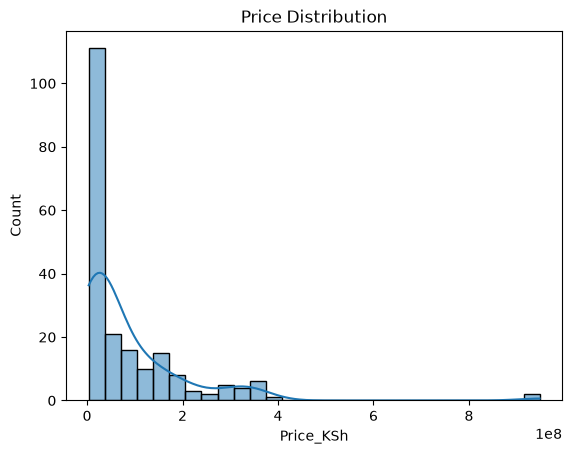

In [6]:
sns.histplot(data['Price_KSh'], kde=True)
plt.title('Price Distribution')
plt.show()


#### Observation: Most houses are in lower price areas

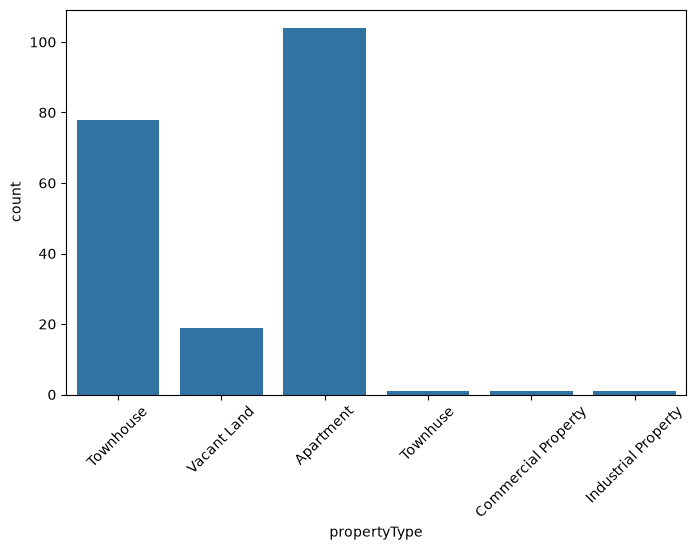

In [7]:
#property type distribution
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="propertyType"
)

plt.xticks(rotation=45)

plt.show()

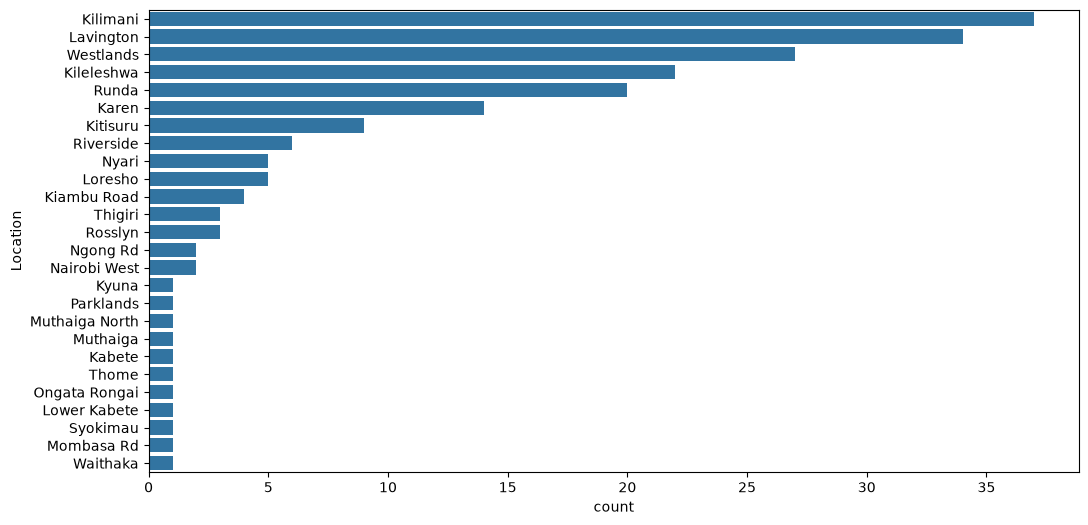

In [8]:
#Location Distribution 
plt.figure(figsize=(12,6))

sns.countplot(
    data=df,
    y="Location",
    order=df["Location"].value_counts().index
)

plt.show()

### Coorelation Analysis

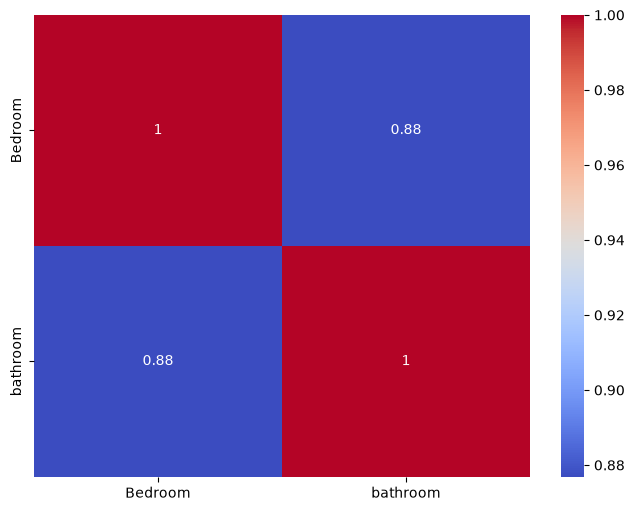

In [9]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(8,6))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.show()

## 6. Outlier Detection

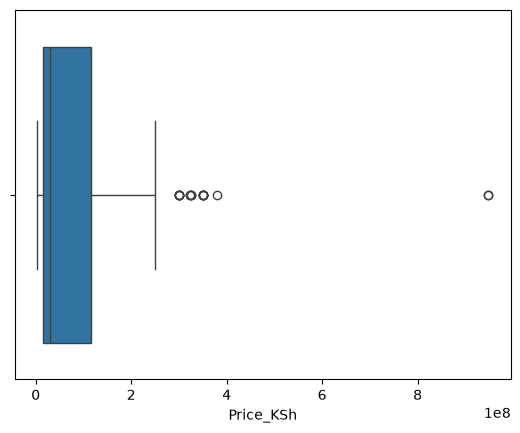

Outliers: 18


In [10]:
sns.boxplot(x=data['Price_KSh'])
plt.show()

Q1 = data['Price_KSh'].quantile(0.25)
Q3 = data['Price_KSh'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5*IQR
upper = Q3 + 1.5*IQR

outliers = data[(data['Price_KSh'] < lower) | (data['Price_KSh'] > upper)]
print('Outliers:', len(outliers))


## 7. Feature Engineering

In [11]:
df["Total_rooms"] = (
    df["Bedroom"].fillna(0)
    +
    df["bathroom"].fillna(0)
)

In [12]:
df["Bedroom_bathroom_ratio"] = (
    df["Bedroom"] /
    (df["bathroom"] + 1)
)

In [13]:
df["House_size_per_bedroom"] = (
    df["House_size_m2"] /
    (df["Bedroom"] + 1)
)

KeyError: 'House_size_m2'

#### Log transformations

In [ ]:
df["House_size_log"] = np.log1p(
    df["House_size_m2"]
)

KeyError: 'House_size_m2'

In [ ]:
df["Land_size_log"] = np.log1p(
    df["Land_size_acres"]
)

KeyError: 'Land_size_acres'

## 8. Feature Selection and Split

In [ ]:
feature_cols = [
    'propertyType','Location','Bedroom','bathroom',
    'House_size_m2','Land_size_acres',
    'Total_rooms','Bedroom_bathroom_ratio',
    'House_size_per_bedroom','House_size_log','Land_size_log'
]

X = data[feature_cols]
y = data['Price_KSh']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


NameError: name 'data' is not defined

## 9. Encoding and Scaling 

In [ ]:
categorical_features = [
    "propertyType",
    "Location"
]


In [ ]:
numeric_features = [
    col
    for col in X.columns
    if col not in categorical_features
]

## 10. Pre processor

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline(
                [
                    (
                        "imputer",
                        SimpleImputer(
                            strategy="median"
                        )
                    ),
                    (
                        "scaler",
                        StandardScaler()
                    )
                ]
            ),
            numeric_features
        ),

        (
            "cat",
            Pipeline(
                [
                    (
                        "imputer",
                        SimpleImputer(
                            strategy="most_frequent"
                        )
                    ),
                    (
                        "encoder",
                        OneHotEncoder(
                            handle_unknown="ignore"
                        )
                    )
                ]
            ),
            categorical_features
        )
    ]
)

## 11. Regression Models

In [ ]:
models = {
    'Linear Regression': LinearRegression(),
    'Ridge': Ridge(),
    'Lasso': Lasso(),
    'Random Forest': RandomForestRegressor(random_state=42)
}


## 12. Model Evaluation

In [ ]:
results = []

for name, model in models.items():
    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])

    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)

    results.append({
        'Model': name,
        'MAE': mean_absolute_error(y_test, preds),
        'RMSE': np.sqrt(mean_squared_error(y_test, preds)),
        'R2': r2_score(y_test, preds)
    })

results_df = pd.DataFrame(results).sort_values('RMSE')
display(results_df)


c:\Users\Nicole Kasiva\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:784: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.595172e+16, tolerance: 2.147e+14
  model = cd_fast.sparse_enet_coordinate_descent(


,Model,MAE,RMSE,R2
1,Ridge,3.735290e+07,5.939069e+07,0.870681
2,Lasso,4.085067e+07,6.267440e+07,0.855986
3,Random Forest,3.279452e+07,6.340741e+07,0.852598
0,Linear Regression,4.322490e+07,6.546298e+07,0.842885


In [ ]:
results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "MAE",
        "RMSE",
        "R2"
    ]
)

results_df.sort_values(
    "RMSE"
)

,Model,MAE,RMSE,R2
1,Ridge,3.735290e+07,5.939069e+07,0.870681
2,Lasso,4.085067e+07,6.267440e+07,0.855986
3,Random Forest,3.279452e+07,6.340741e+07,0.852598
0,Linear Regression,4.322490e+07,6.546298e+07,0.842885


## 13. Best Model

In [ ]:
best_model = Pipeline([
    ("preprocessor", preprocessor),
    (
        "model",
        RandomForestRegressor(
            random_state=42
        )
    )
])

best_model.fit(
    X_train,
    y_train
)

predictions = best_model.predict(
    X_test
)

## 14. Error Analysis

In [ ]:
best_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(random_state=42))
])

best_model.fit(X_train, y_train)
predictions = best_model.predict(X_test)

errors = y_test - predictions
errors.describe()


count    4.100000e+01
mean     2.489592e+07
std      5.903990e+07
min     -4.673214e+07
25%     -3.753132e+06
50%     -1.373333e+04
75%      2.558000e+07
max      2.385670e+08
Name: Price_KSh, dtype: float64

## 15. Residual Plot

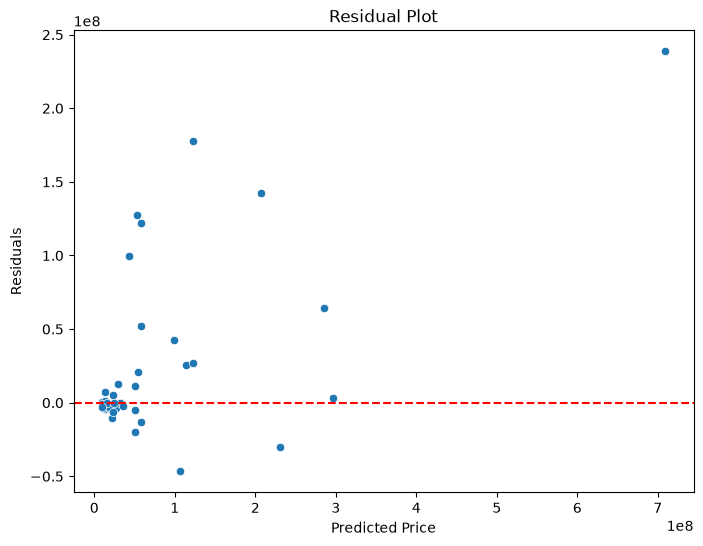

In [ ]:
residuals = y_test - predictions

plt.figure(figsize=(8,6))
sns.scatterplot(x=predictions, y=residuals)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Predicted Price')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.show()


## 13. Conclusion
### Random Forest achieved the best performance with the lowest RMSE and highest R² score. The model successfully captured the relationship between property characteristics and house prices.